# 🆎 **Introducción a Clustering**

Clustering es una técnica de **aprendizaje no supervisado** que consiste en agrupar datos similares entre sí **sin usar etiquetas** o categorías predefinidas.

#### 🎯 **¿Para qué se usa?**

* Segmentación de clientes en marketing.

* Agrupación de documentos por temas.

* Detección de patrones en datos sin estructura.

* Análisis exploratorio de datos desconocidos.

* Reducción de ruido o compresión de datos.

#### ⚙️ **¿Cómo funciona?**

* Recibe un conjunto de datos sin clasificar.

* Calcula similitudes o distancias entre puntos (ej. euclidiana).

* Agrupa elementos que están cerca entre sí, formando clusters.

* Optimiza una función de agrupamiento, como la variación interna del grupo.

#### 🎯 **Propósito**

El **objetivo principal** del clustering es **descubrir estructura oculta** en los datos, organizando los elementos en grupos internamente coherentes y externamente distintos.

Es una herramienta esencial para explorar datos, reducir su complejidad y revelar relaciones que no son evidentes a simple vista.

## 🐍 **¡Primera implementación en Python!**

### 📖 **Implementación de Librerías**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### 🏓 **Carga del dataset**

El conjunto de datos **Iris** es uno de los más clásicos y utilizados en estadística y ciencia de datos. Fue introducido por el estadístico **Ronald A. Fisher** en 1936.

#### **📊 ¿Qué contiene?**

La tabla contiene **150 observaciones** de flores del género *Iris*, divididas en tres especies:

- *Iris setosa*  
- *Iris versicolor*  
- *Iris virginica*  

Cada flor tiene **cuatro características numéricas**:

- `sepal_length`: Longitud del sépalo  
- `sepal_width`: Ancho del sépalo  
- `petal_length`: Longitud del pétalo  
- `petal_width`: Ancho del pétalo  

También incluye una columna con la **especie de la flor** (`species`), aunque esta no se usa en tareas no supervisadas como clustering.

Ya que conocemos esta tabla, podemos usarla para aplicar técnicas de agrupamiento como **K-means**, ignorando la columna de especie para simular un escenario sin etiquetas.

In [ ]:
# Cargar datos (usaremos iris aprovechando que ya la conocemos)
iris = sns.load_dataset("iris")
X = iris[["sepal_length", "sepal_width"]].values

#### 🧲 **Parámetros**

### ⚙️ **Parámetros principales de K-Means**

- `K`: Número de clusters a formar. Debe elegirse antes de ejecutar el algoritmo.

- `max_iter`: Número máximo de iteraciones. Limita cuántas veces se repiten los pasos de asignación y actualización.  
  Aunque el algoritmo suele **converger antes** (cuando los centroides ya no cambian), este parámetro evita ciclos infinitos.


In [ ]:
# Parámetros
K = 3
max_iter = 100

### 🎯 **Inicialización de centroides**

En K-Means, los centroides se **inicializan aleatoriamente** a partir de puntos del conjunto de datos.

Esta elección inicial puede afectar:
- La **velocidad de convergencia**,
- Y la **calidad de los clusters** (puede caer en mínimos locales).

Más adelante, se pueden usar estrategias más robustas como **K-Means++**, que mejora la distribución inicial de los centroides para obtener mejores resultados.


In [ ]:
np.random.seed(0)

# Inicialización aleatoria de centroides
centroids = X[np.random.choice(len(X), K, replace=False)]

In [ ]:
centroids

### 👩🏻‍💻👨🏻‍💻 **Implementación de Algoritmo**

In [ ]:
# Visualización por iteración
def plot_iteration(X, labels, centroids, iteration):
    colors = ['red', 'green', 'blue']
    plt.figure(figsize=(6, 5))
    for k in range(K):
        cluster_points = X[labels == k]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[k], label=f'Cluster {k+1}')

    plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroides')
    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title(f"K-Means - Iteración {iteration}")
    plt.legend()
    plt.show()

In [ ]:
# Algoritmo con visualización por iteración
for i in range(1, max_iter + 1):
    # Asignación
    labels = []
    for point in X:
        distances = [np.linalg.norm(point - c) for c in centroids]
        labels.append(np.argmin(distances))
    labels = np.array(labels)

    # Visualización en esta iteración
    plot_iteration(X, labels, centroids, i)

    # Actualización
    new_centroids = []
    for k in range(K):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            new_centroids.append(cluster_points.mean(axis=0))
        else:
            new_centroids.append(centroids[k])
    new_centroids = np.array(new_centroids)

    # Verificar convergencia
    #if np.allclose(centroids, new_centroids):
    #    break
    centroids = new_centroids

### 🧪 **Implementación con `KMeans` de `sckit-learn`**

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# Cargar datos
iris = sns.load_dataset("iris")
X = iris[["sepal_length", "sepal_width"]].values

In [ ]:
iris[["sepal_length", "sepal_width"]].values

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

In [ ]:
# Aplicar K-Means con funciones de sklearn
kmeans = KMeans(n_clusters=3, init='random', n_init=1, max_iter=100, random_state=0)
kmeans.fit(X)

KMeans(init='random', max_iter=100, n_clusters=3, n_init=1, random_state=0)

In [ ]:
# Obtener etiquetas y centroides
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

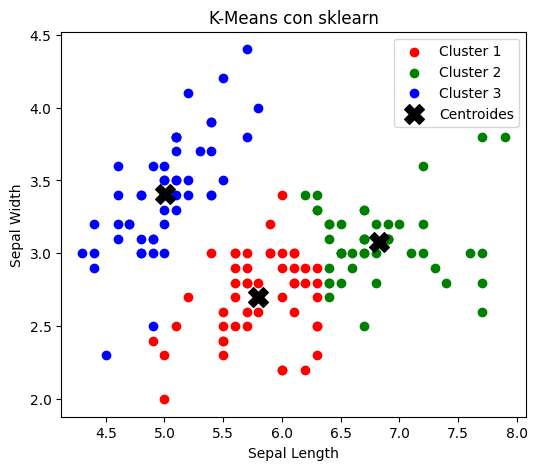

In [ ]:
# Visualización
colors = ['red', 'green', 'blue']
plt.figure(figsize=(6, 5))
for k in range(3):
    cluster_points = X[labels == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[k], label=f'Cluster {k+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroides')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means con sklearn")
plt.legend()
plt.show()